In [4]:
import pandas as pd
import numpy as np

DATA_PATH = "wbes_sintetico.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head()


Shape: (1200, 11)


,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
0,13.0,10.0,1.0,1.0,0,1,Media,Manufactura,42879.327130,5374.714150,1
1,9.0,6.0,0.0,0.0,0,1,Baja,Servicios,54570.897174,4728.282631,0
2,15.0,10.0,0.0,0.0,1,1,Baja,Servicios,56311.260030,3104.627628,0
3,25.0,12.0,1.0,0.0,1,1,Baja,Servicios,93419.359675,3129.017055,1
4,9.0,9.0,0.0,0.0,0,0,Baja,Manufactura,24608.889361,2824.645056,1


In [5]:
# 1) Limpieza y comprensión de datos

cols = [
    "sales_annual_usd",
    "labor_productivity_usd_per_employee",
    "employees",
    "firm_age_years",
    "access_finance",
    "training",
    "competition_level",
    "exporter",
    "digital_payments",
    "sector",
]

missing = [c for c in cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Faltan columnas en el CSV: {missing}")

df = df_raw[cols].copy()

print("Nulos por columna:")
display(df.isna().sum())

df_clean = df.dropna().reset_index(drop=True)

print("\nShape original:", df.shape)
print("Shape limpio:", df_clean.shape)

display(df_clean.describe(include="all"))
df_clean.head()


Nulos por columna:


sales_annual_usd                       27
labor_productivity_usd_per_employee     0
employees                              10
firm_age_years                         26
access_finance                         35
training                               33
competition_level                      33
exporter                                0
digital_payments                        0
sector                                 13
dtype: int64


Shape original: (1200, 10)
Shape limpio: (1035, 10)


,sales_annual_usd,labor_productivity_usd_per_employee,employees,firm_age_years,access_finance,training,competition_level,exporter,digital_payments,sector
count,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000,1035,1035.000000,1035.000000,1035
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,Media,NaN,NaN,Servicios
freq,NaN,NaN,NaN,NaN,NaN,NaN,523,NaN,NaN,420
mean,29803.665875,2978.822092,12.206763,9.335266,0.353623,0.421256,NaN,0.183575,0.583575,NaN
std,17316.649436,1895.857080,8.261429,5.644074,0.478325,0.493999,NaN,0.387324,0.493204,NaN
min,4616.266871,504.745429,1.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,17908.343915,1696.484991,7.000000,5.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
50%,26037.930090,2560.540352,10.000000,9.000000,0.000000,0.000000,NaN,0.000000,1.000000,NaN
75%,37280.646989,3697.058446,15.000000,13.000000,1.000000,1.000000,NaN,0.000000,1.000000,NaN


,sales_annual_usd,labor_productivity_usd_per_employee,employees,firm_age_years,access_finance,training,competition_level,exporter,digital_payments,sector
0,42879.327130,5374.714150,13.0,10.0,1.0,1.0,Media,0,1,Manufactura
1,54570.897174,4728.282631,9.0,6.0,0.0,0.0,Baja,0,1,Servicios
2,56311.260030,3104.627628,15.0,10.0,0.0,0.0,Baja,1,1,Servicios
3,93419.359675,3129.017055,25.0,12.0,0.0,1.0,Baja,1,1,Servicios
4,24608.889361,2824.645056,9.0,9.0,0.0,0.0,Baja,0,0,Manufactura


In [6]:
# Estandarizacion de tipos
bin_cols = ["access_finance", "training", "exporter", "digital_payments"]
for c in bin_cols:
    df_clean[c] = df_clean[c].round().astype(int)

cat_cols = ["competition_level", "sector"]
for c in cat_cols:
    df_clean[c] = df_clean[c].astype("category")

df_clean.dtypes


sales_annual_usd                        float64
labor_productivity_usd_per_employee     float64
employees                               float64
firm_age_years                          float64
access_finance                            int64
training                                  int64
competition_level                      category
exporter                                  int64
digital_payments                          int64
sector                                 category
dtype: object

## 2) Regresión Lineal

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import pandas as pd

X = df_clean[
    ["employees","firm_age_years","training","access_finance","exporter","digital_payments","competition_level","sector"]
].copy()

num_features = ["employees","firm_age_years"]
bin_features = ["training","access_finance","exporter","digital_payments"]
cat_features = ["competition_level","sector"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features + bin_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

def fit_linear(y_col, test_size=0.2, random_state=42):
    y = df_clean[y_col].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = Pipeline(steps=[
        ("prep", preprocess),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    return model, (X_train, X_test, y_train, y_test, y_pred), (r2, mse)

model_sales, pack_sales, metrics_sales = fit_linear("sales_annual_usd")
model_prod,  pack_prod,  metrics_prod  = fit_linear("labor_productivity_usd_per_employee")

print("Ventas   -> R2:", metrics_sales[0], " MSE:", metrics_sales[1])
print("Prod.    -> R2:", metrics_prod[0],  " MSE:", metrics_prod[1])


Ventas   -> R2: 0.4610948114283465  MSE: 232578828.65764552
Prod.    -> R2: 0.2696033950765264  MSE: 3358873.7751276176


In [25]:
# Coeficientes

def get_feature_names(preprocess):
    num_names = num_features + bin_features
    ohe = preprocess.named_transformers_["cat"]
    cat_names = list(ohe.get_feature_names_out(cat_features))
    return num_names + cat_names

def coefficients_table(pipeline_model):
    prep = pipeline_model.named_steps["prep"]
    lr = pipeline_model.named_steps["lr"]
    feat_names = get_feature_names(prep)
    coefs = pd.Series(lr.coef_, index=feat_names).sort_values(key=lambda s: s.abs(), ascending=False)
    return coefs

coefs_sales = coefficients_table(model_sales)
coefs_prod  = coefficients_table(model_prod)

print("Top coeficientes |Ventas|:")
display(coefs_sales.head(15))

print("Top coeficientes |Productividad|:")
display(coefs_prod.head(15))


Top coeficientes |Ventas|:


access_finance             8096.975871
exporter                   6495.261014
training                   6307.749612
competition_level_Alta    -4115.334755
competition_level_Baja     3686.449761
sector_Comercio           -2868.549450
sector_Manufactura         1825.891244
sector_Tecnologia          1558.575820
digital_payments           1226.042583
employees                  1162.806456
firm_age_years              533.707039
sector_Servicios           -515.917615
competition_level_Media     428.884994
dtype: float64

Top coeficientes |Productividad|:


training                   748.819072
exporter                   699.365594
access_finance             693.271767
competition_level_Baja     454.271719
competition_level_Alta    -387.788294
sector_Tecnologia          336.498135
sector_Comercio           -282.289945
digital_payments           206.808892
sector_Servicios          -133.617287
employees                  -92.156854
sector_Manufactura          79.409098
competition_level_Media    -66.483425
firm_age_years              54.729281
dtype: float64

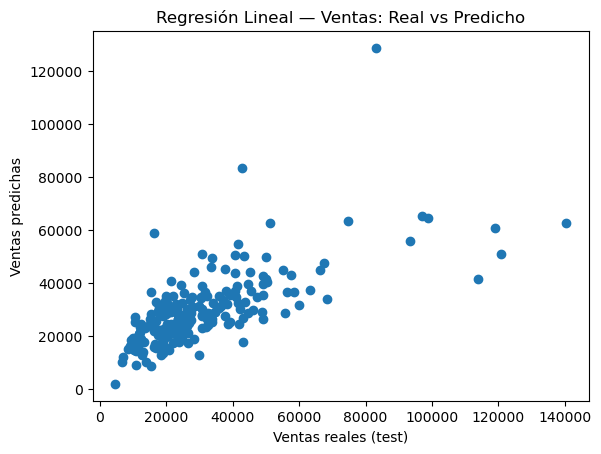

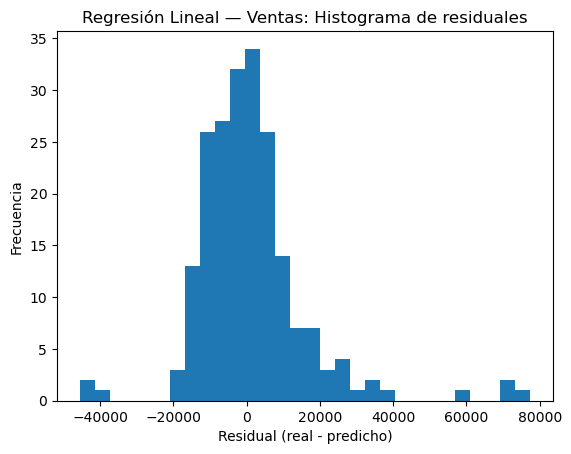

In [9]:
# Graficas de ventas): real vs predicho + residuales

X_train, X_test, y_train, y_test, y_pred = pack_sales

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Ventas reales (test)")
plt.ylabel("Ventas predichas")
plt.title("Regresión Lineal — Ventas: Real vs Predicho")
plt.show()

residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (real - predicho)")
plt.ylabel("Frecuencia")
plt.title("Regresión Lineal — Ventas: Histograma de residuales")
plt.show()


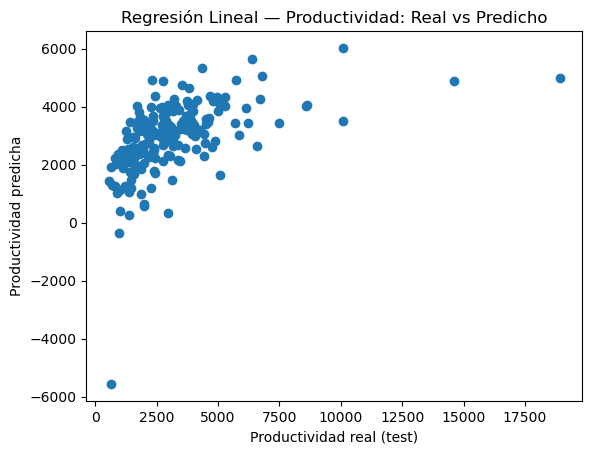

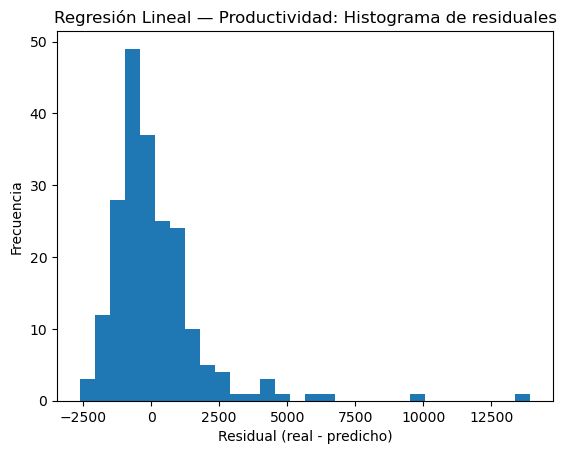

In [10]:
# Graficas de productividad: real vs predicho + residuales

X_train, X_test, y_train, y_test, y_pred = pack_prod

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Productividad real (test)")
plt.ylabel("Productividad predicha")
plt.title("Regresión Lineal — Productividad: Real vs Predicho")
plt.show()

residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (real - predicho)")
plt.ylabel("Frecuencia")
plt.title("Regresión Lineal — Productividad: Histograma de residuales")
plt.show()


## 3) Regresión Logística

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# Etiqueta según regla
sales_mean = df_clean["sales_annual_usd"].mean()
df_clean["successful_rule"] = (df_clean["sales_annual_usd"] > sales_mean).astype(int)

X_cls = df_clean[["employees","training","exporter","access_finance","competition_level"]].copy()
y_cls = df_clean["successful_rule"].copy()

num_features_cls = ["employees"]
bin_features_cls = ["training","exporter","access_finance"]
cat_features_cls = ["competition_level"]

preprocess_cls = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features_cls + bin_features_cls),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_cls),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

logit = Pipeline(steps=[
    ("prep", preprocess_cls),
    ("clf", LogisticRegression(max_iter=2000))
])

logit.fit(X_train, y_train)

y_pred = logit.predict(X_test)
y_prob = logit.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
cm


Accuracy: 0.7922705314009661


array([[115,   9],
       [ 34,  49]])

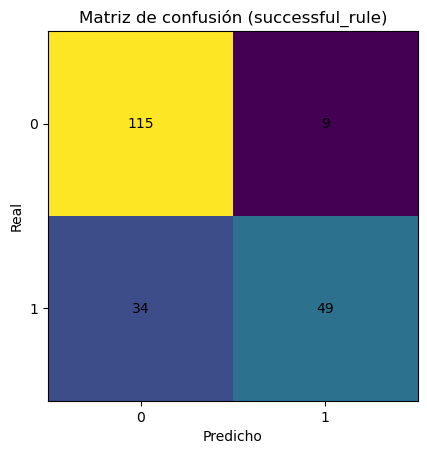

In [19]:
# Matriz de confusión (visual simple)
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(cm)
plt.title("Matriz de confusión (successful_rule)")
plt.xlabel("Predicho")
plt.ylabel("Real")
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha="center", va="center")
plt.xticks([0,1],[0,1])
plt.yticks([0,1],[0,1])
plt.show()


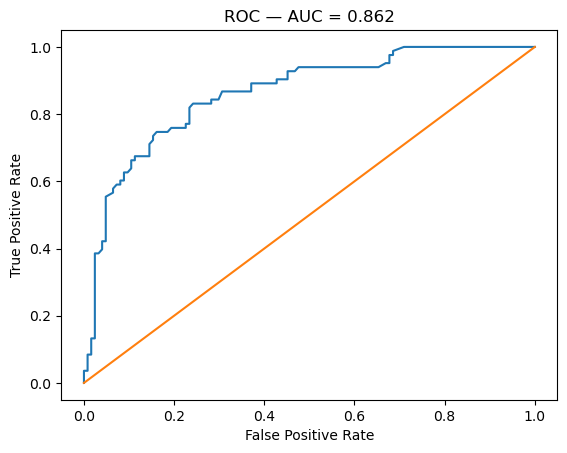

0.862174504469491

In [20]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC — AUC = {roc_auc:.3f}")
plt.show()

roc_auc


In [21]:
# Coeficientes del modelo logístico
import pandas as pd

prep = logit.named_steps["prep"]
clf = logit.named_steps["clf"]

num_names = num_features_cls + bin_features_cls
cat_names = list(prep.named_transformers_["cat"].get_feature_names_out(cat_features_cls))
feat_names = num_names + cat_names

coefs = pd.Series(clf.coef_[0], index=feat_names).sort_values(key=lambda s: s.abs(), ascending=False)
display(coefs.head(15))


access_finance             0.949615
exporter                   0.908414
training                   0.866352
competition_level_Alta    -0.453917
competition_level_Baja     0.371089
employees                  0.164591
competition_level_Media    0.084696
dtype: float64

## 4) Red Bayesiana

In [22]:
# Intentar pgmpy
try:
    from pgmpy.models import DiscreteBayesianNetwork
    from pgmpy.estimators import MaximumLikelihoodEstimator
    from pgmpy.inference import VariableElimination
    import networkx as nx
    PGMPY_AVAILABLE = True
except Exception as e:
    PGMPY_AVAILABLE = False
    print("pgmpy no está disponible. Error:", repr(e))

PGMPY_AVAILABLE


True

In [23]:
bn_df = df_clean[["successful_rule","training","access_finance","competition_level","exporter"]].copy()
bn_df["competition_level"] = bn_df["competition_level"].astype(str)
bn_df.head()


,successful_rule,training,access_finance,competition_level,exporter
0,1,1,1,Media,0
1,1,0,0,Baja,0
2,1,0,0,Baja,1
3,1,1,0,Baja,1
4,0,0,0,Baja,0


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'successful_rule': 'N', 'training': 'N', 'access_finance': 'N', 'competition_level': 'C', 'exporter': 'N'}


CPDs:
+-------------------+----------+
| access_finance(0) | 0.646377 |
+-------------------+----------+
| access_finance(1) | 0.353623 |
+-------------------+----------+
------------------------------------------------------------
+----------------+--------------------+--------------------+
| access_finance | access_finance(0)  | access_finance(1)  |
+----------------+--------------------+--------------------+
| training(0)    | 0.5979073243647235 | 0.5437158469945356 |
+----------------+--------------------+--------------------+
| training(1)    | 0.4020926756352765 | 0.4562841530054645 |
+----------------+--------------------+--------------------+
------------------------------------------------------------
+--------------------+-----+--------------------------+
| access_finance     | ... | access_finance(1)        |
+--------------------+-----+--------------------------+
| competition_level  | ... | competition_level(Media) |
+--------------------+-----+--------------------------+


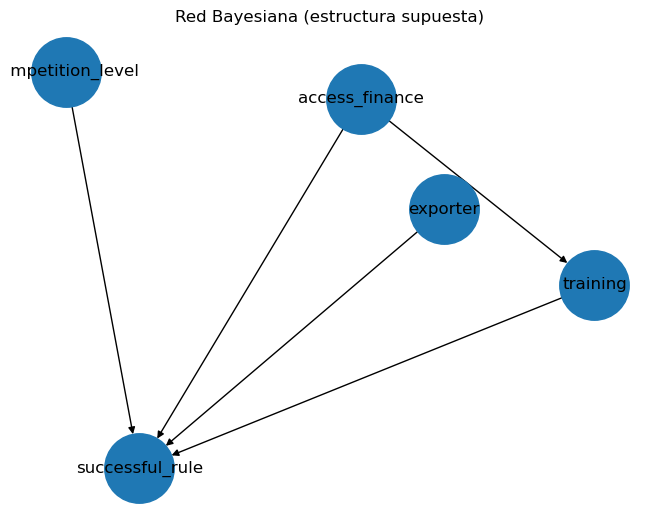

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

if PGMPY_AVAILABLE:
    model_bn = DiscreteBayesianNetwork([
        ("access_finance","training"),
        ("access_finance","successful_rule"),
        ("training","successful_rule"),
        ("competition_level","successful_rule"),
        ("exporter","successful_rule"),
    ])

    model_bn.fit(bn_df, estimator=MaximumLikelihoodEstimator)

    print("CPDs:")
    for cpd in model_bn.get_cpds():
        print(cpd)
        print("-"*60)

    infer = VariableElimination(model_bn)
    q = infer.query(variables=["successful_rule"], evidence={"access_finance":1, "training":1})
    print("P(successful_rule | access_finance=1, training=1):")
    print(q)

    G = nx.DiGraph(model_bn.edges())
    plt.figure()
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=2500)
    plt.title("Red Bayesiana (estructura supuesta)")
    plt.show()
else:
    print("Fallback: tablas P(successful_rule | access_finance, training)")
    ct = pd.crosstab(
        index=[bn_df["access_finance"], bn_df["training"]],
        columns=bn_df["successful_rule"],
        normalize="index"
    )
    display(ct)


## 5) Conclusión
Los resultados indican que variables como el acceso a financiamiento, la capacitación y el tamaño de la empresa si influyen en el desempeño empresarial. La regresión lineal mostró que estas variables explican una parte relevante de las ventas, aunque no toda su variación. La regresión logística presentó una buena capacidad para clasificar empresas exitosas (AUC alto), y la red bayesiana evidenció que combinar financiamiento y capacitación incrementa notablemente la probabilidad de éxito.

Para tomar decisiones, los modelos de clasificación y la red bayesiana pueden ser más prácticos que la regresión lineal, porque ayudan a identificar qué empresas tienen mayor probabilidad de ser exitosas y a quién convendría apoyar primero. Aun así, los resultados muestran relaciones estadísticas y probabilidades, no una causa directa, por lo que deben usarse como guía y no como una verdad absoluta al momento de diseñar políticas